In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.utils import resample

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
crime = pd.read_csv('/content/drive/MyDrive/Data Science Final Project/crime_df.csv')
census = pd.read_csv('/content/drive/MyDrive/Data Science Final Project/Census.csv')

Combining the crime dataset and the census dataset and aggregating it to be a per year level per city.

In [ ]:
city_year = crime.groupby(['City', 'Year']).agg(
    Total_Arrests = ('Crime', 'count'),
    Avg_Violence_Score = ('Violence Rating', 'mean'),
    Violent_Crime_Count = ('Violence Rating', lambda x: (x >= 6).sum())
).reset_index()

In [ ]:
census.head()

,City,Population,Income (dollars),Education (percent),Employment (percent),HousingUnits,Health (percent),Households,Age,Language (percent),...,Homeownership Rate(percent),Largest Housing Value,Disability (percent),Marital Status (percent),American Indian and Alaska Native,Asian,Black or African American,Hispanic or Latino,Native Hawaiian and Other Pacific Islander,White
0,New York,8804190,81228,42.5,59.3,3737632,5.9,3379651,38.5,48.3,...,32.7,500000-999999,13.8,45.4,86218,1385144,1943645,2490350,6874,3000945
1,Los Angeles,3898747,82263,39.9,62.7,1587311,8.5,1480869,37.5,56.6,...,35.9,1000000+,11.8,47.2,66491,462643,336096,1829991,5960,1359068
2,Chicago,2746388,80613,46.4,64.1,1282248,9.6,1172455,35.9,35.4,...,46.5,300000-499999,11.9,50.7,34543,192586,801195,819518,1087,986280
3,Detroit,639111,39209,18.8,48.8,343649,7.5,268048,35.9,14.1,...,51.0,50000-99999,19.0,57.4,2931,10193,496534,51269,160,68407
4,Seattle,737015,118745,70.1,71.5,411671,3.7,383698,35.4,24.3,...,41.9,1000000+,10.4,47.6,5197,125668,51419,60563,2109,451623


In [ ]:
city_year.head()

,City,Year,Total_Arrests,Avg_Violence_Score,Violent_Crime_Count
0,Austin,2018,365,3.016438,86
1,Austin,2019,365,2.953425,78
2,Austin,2020,366,3.000000,80
3,Austin,2021,365,2.972603,85
4,Austin,2022,365,3.000000,78


In [ ]:
city_year['Violent_Crime_Rate'] = (
    city_year['Violent_Crime_Count'] / city_year['Total_Arrests'] * 100
)

In [ ]:
master_df = pd.merge(city_year, census, on='City', how='left')

In [ ]:
master_df.head()

,City,Year,Total_Arrests,Avg_Violence_Score,Violent_Crime_Count,Violent_Crime_Rate,Population,Income (dollars),Education (percent),Employment (percent),...,Homeownership Rate(percent),Largest Housing Value,Disability (percent),Marital Status (percent),American Indian and Alaska Native,Asian,Black or African American,Hispanic or Latino,Native Hawaiian and Other Pacific Islander,White
0,Austin,2018,365,3.016438,86,23.561644,961855,90430,60.7,72.2,...,43.4,500000-999999,7.6,56.0,9277,86876,69757,312448,708,526024
1,Austin,2019,365,2.953425,78,21.369863,961855,90430,60.7,72.2,...,43.4,500000-999999,7.6,56.0,9277,86876,69757,312448,708,526024
2,Austin,2020,366,3.000000,80,21.857923,961855,90430,60.7,72.2,...,43.4,500000-999999,7.6,56.0,9277,86876,69757,312448,708,526024
3,Austin,2021,365,2.972603,85,23.287671,961855,90430,60.7,72.2,...,43.4,500000-999999,7.6,56.0,9277,86876,69757,312448,708,526024
4,Austin,2022,365,3.000000,78,21.369863,961855,90430,60.7,72.2,...,43.4,500000-999999,7.6,56.0,9277,86876,69757,312448,708,526024


In [ ]:
#save master_df as csv
master_df.to_csv('master_df.csv', index=False)

# **Feature Engineering**

In [ ]:
#transforming skewed columns/extreme differences
log_cols = [
    'Population',
    'HousingUnits',
    'Households',
    'Asian',
    'Black or African American',
    'White',
    'Hispanic or Latino',
    'American Indian and Alaska Native',
    'Poverty (percent)',
    'Residential Mobility (percent)',
]

In [ ]:
#new variable as log variable
for col in log_cols:
  # Convert to string to ensure .str accessor is available, remove commas, then convert to numeric
  master_df[col] = master_df[col].astype(str).str.replace(',', '', regex=False).astype(float)
  master_df[f'log_{col}'] = np.log1p(master_df[col])

In [ ]:
#dropping columns I don't want to use as feature values and the nonlogged versions
drop_cols = [
    'City',
    'Year',
    'Avg_Violence_Score',
    'Violent_Crime_Count',
    'Violent_Crime_Rate',
    'Total_Arrests',
    'Largest Housing Value',
] + log_cols

In [ ]:
features = [col for col in master_df.columns if col not in drop_cols]
X = master_df[features]
#dependent variable violence score
y = master_df['Avg_Violence_Score']

In [ ]:
#standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
citycolors = {
    'Austin' : '#FF7F50',
    'Chicago' : '#0343DF',
    'Detroit' : '#008000',
    'Los Angeles': '#FAC205',
    'New York': '#E50000',
    'San Francisco' : '#FF81C0',
    'Seattle' : '#00FFFF',
}

In [ ]:
plt.rcParams.update({
    'axes.spines.top' : False,
    'axes.spines.right' : False,
    'axes.facecolor' : '#f8f9fa',
    'figure.facecolor' : 'white',
    'axes.grid' : True,
    'grid.alpha' : 0.3,
    'grid.linestyle' : '--',
})

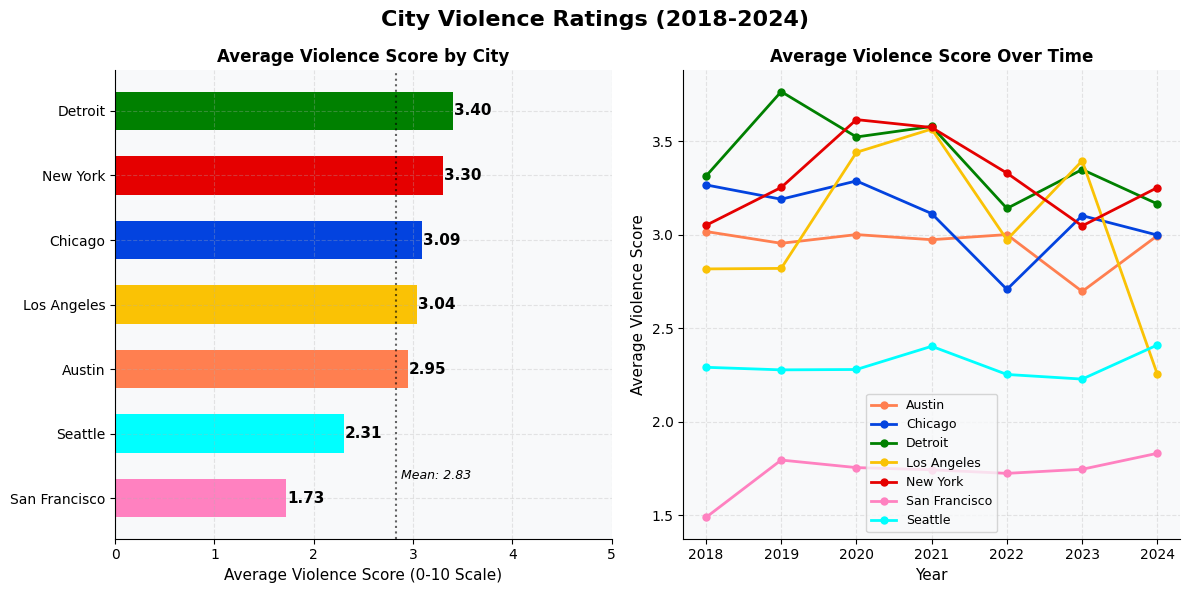

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle('City Violence Ratings (2018-2024)', fontsize = 16, fontweight='bold')

#LEFT SIDE, BAR CHART FOR CITY DISTRIBUTION
ax = axes[0]
violence_avg = master_df.groupby('City')['Avg_Violence_Score'].mean().sort_values(ascending=True)
colors = [citycolors[city] for city in violence_avg.index]
#making horizontal bars for easy read
bars = ax.barh(violence_avg.index, violence_avg.values, color=colors, height = 0.6)

#Assigning city names to bars
for bar, val in zip(bars, violence_avg.values):
  ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', ha='left', va='center',
          fontsize = 11, fontweight='bold')

#mean bar
ax.axvline(violence_avg.mean(), color = 'black', linestyle=':', linewidth=1.5,
           alpha = 0.6)
ax.text(violence_avg.mean() + 0.05, 0.3,
        f'Mean: {violence_avg.mean():.2f}', fontsize=9, color = 'black', style = 'italic')

ax.set_xlabel('Average Violence Score (0-10 Scale)', fontsize = 11)
ax.set_title('Average Violence Score by City', fontsize = 12, fontweight='bold')
ax.set_xlim(0, 5)

#second graph -- crime over time
ax = axes[1]

for city in sorted(master_df['City'].unique()):
  subset = master_df[master_df['City'] == city].sort_values('Year')
  ax.plot(subset['Year'], subset['Avg_Violence_Score'],
          marker = 'o', markersize = 5, linewidth = 2,
          label = city, color = citycolors[city])

ax.set_xlabel('Year', fontsize = 11)
ax.set_ylabel('Average Violence Score', fontsize = 11)
ax.set_title('Average Violence Score Over Time', fontsize = 12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(sorted(master_df['Year'].unique()))

plt.tight_layout()
plt.show()

# **Principal Component Analysis**

In [ ]:
#keep components that explain 90% of data
pca = PCA(n_components=0.9, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(f"PCA: {X_scaled.shape[1]} features -> {X_pca.shape[1]} components")
print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
for i, var in enumerate(pca.explained_variance_ratio_):
  print(f"PC {i+1}: {var*100:.1f}%")

PCA: 31 features -> 3 components
Variance explained: 93.2%
PC 1: 43.2%
PC 2: 35.0%
PC 3: 15.1%


Three components explain 93.2% of the variance

In [ ]:
feature_names = features
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("\n Top 3 features driving each component:")
for pc in components_df.index:
  top3 = components_df.loc[pc].abs().nlargest(3).index.tolist()
  print(f"{pc}: {', '.join(top3)}")
print()


 Top 3 features driving each component:
PC1: log_Asian, Foreign-born (percent), Homeownership Rate(percent)
PC2: log_Black or African American, Graduate or Professional (percent), Education (percent)
PC3: Health (percent), Older Pop (percent), Age



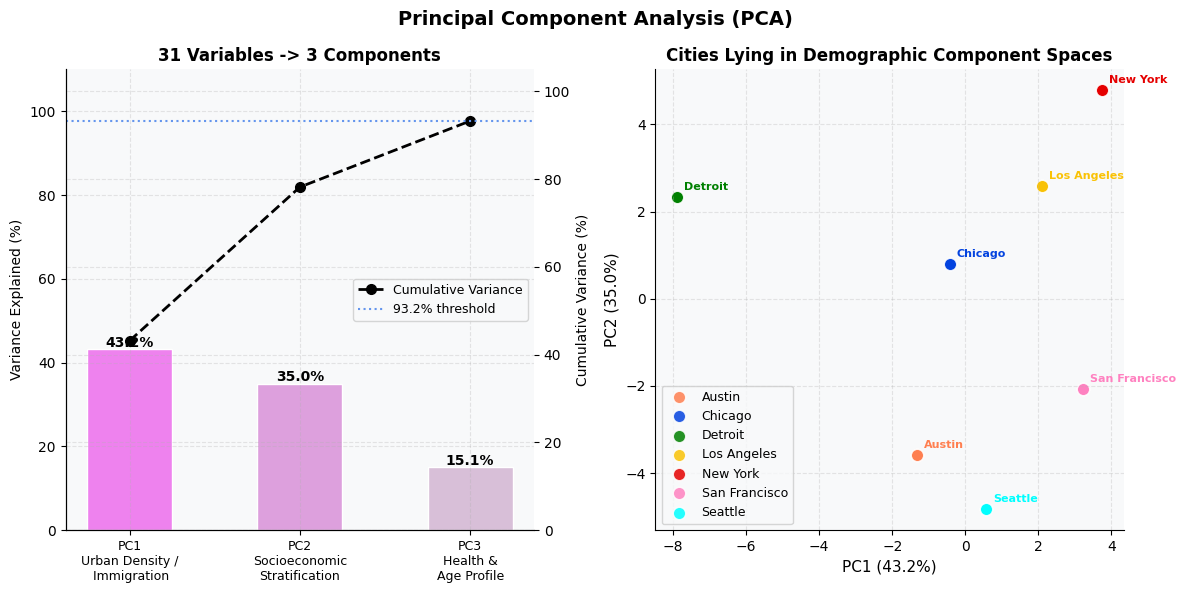

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (12, 6))
fig.suptitle('Principal Component Analysis (PCA)', fontsize = 14, fontweight='bold')

#Left panel: scree plot
ax = axes[0]

var_ratio = pca.explained_variance_ratio_*100
cum_var = np.cumsum(var_ratio)
x_pos = np.arange(1, len(var_ratio) + 1)

bars = ax.bar(x_pos, var_ratio, color = ['violet', 'plum', 'thistle'],
              edgecolor = 'white', width = 0.5)

ax2 = ax.twinx()
ax2.plot(x_pos, cum_var, 'ko--', linewidth=2, markersize=7, label='Cumulative Variance')
ax2.set_ylim(0, 105)
ax2.axhline(93.2, color = 'cornflowerblue', linestyle=':', linewidth=1.5, label = '93.2% threshold')
ax2.legend(loc='center right', fontsize = 9)
ax2.set_ylabel('Cumulative Variance (%)', fontsize = 10)
ax2.spines['top'].set_visible(False)

for bar, val in zip(bars, var_ratio):
  ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%',
          ha='center', fontsize = 10, fontweight = 'bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([
    'PC1\nUrban Density /\n Immigration',
    'PC2\nSocioeconomic\nStratification',
    'PC3\nHealth &\nAge Profile'
], fontsize = 9)
ax.set_ylabel('Variance Explained (%)', fontsize = 10)
ax.set_ylim(0,110)
ax.set_title('31 Variables -> 3 Components', fontsize = 12, fontweight='bold')

ax = axes[1]

cities = master_df['City'].values

for city in sorted(master_df['City'].unique()):
  mask = cities == city
  ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
             c = citycolors[city], label = city,
             s=80, alpha =0.85, edgecolors = 'white')

  cx=X_pca[mask, 0].mean()
  cy=X_pca[mask, 1].mean()
  ax.annotate(city, xy =(cx,cy), xytext=(5,5),
              textcoords = 'offset points', fontsize = 8,
              fontweight = 'bold', color = citycolors[city])

ax.set_xlabel('PC1 (43.2%)', fontsize = 11)
ax.set_ylabel('PC2 (35.0%)', fontsize = 11)
ax.set_title('Cities Lying in Demographic Component Spaces', fontsize = 12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# **Cross Validation**

In [ ]:
#cross validation setup (5 k fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
#model for cv
def evaluate_model(name, model, X, y, cv):
  scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
  rmse_scores = np.sqrt(-cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error'))
  print(f"{name:<20} R^2: {scores.mean():.3f} +/- {scores.std():.3f} | "
        f"RMSE: {rmse_scores.mean():.3f} +/- {rmse_scores.std():.3f}")
  return scores

# **Linear Regression**

In [ ]:
#linear regression model
print("Model Results (5-fold cross validation):")
lr = LinearRegression()
lr_scores = evaluate_model("Linear Regression", lr, X_pca, y, kf)

Model Results (5-fold cross validation):
Linear Regression    R^2: 0.714 +/- 0.184 | RMSE: 0.262 +/- 0.065


In [ ]:
#coefficient interpretation
lr.fit(X_pca, y)
print(f" Coefficients: {[f'PC{i+1}: {c:.3f}' for i, c in enumerate(lr.coef_)]}")

 Coefficients: ['PC1: -0.069', 'PC2: 0.115', 'PC3: 0.142']


# **Ridge Regression**

In [ ]:
#ridge regression
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=kf)
ridge.fit(X_pca, y)
ridge_scores = evaluate_model("Ridge Regression", ridge, X_pca, y, kf)
print(f" Best alpha: {ridge.alpha_}")
#

Ridge Regression     R^2: 0.714 +/- 0.181 | RMSE: 0.263 +/- 0.064
 Best alpha: 0.01


# **Lasso Regression**

In [ ]:
#lasso regression
lasso = LassoCV(cv=kf, random_state=42, max_iter = 10000)
lasso.fit(X_pca, y)
lasso_scores = evaluate_model("Lasso Regression", lasso, X_pca, y, kf)
print(f" Best alpha: {lasso.alpha_:.4f}")
nonzero = np.sum(lasso.coef_ != 0)
print(f" Nonzero coefficients: {nonzero}/{X_pca.shape[1]} components kept\n")
#

Lasso Regression     R^2: 0.716 +/- 0.183 | RMSE: 0.261 +/- 0.065
 Best alpha: 0.0012
 Nonzero coefficients: 3/3 components kept



All three of the principal components are relevant in the model.

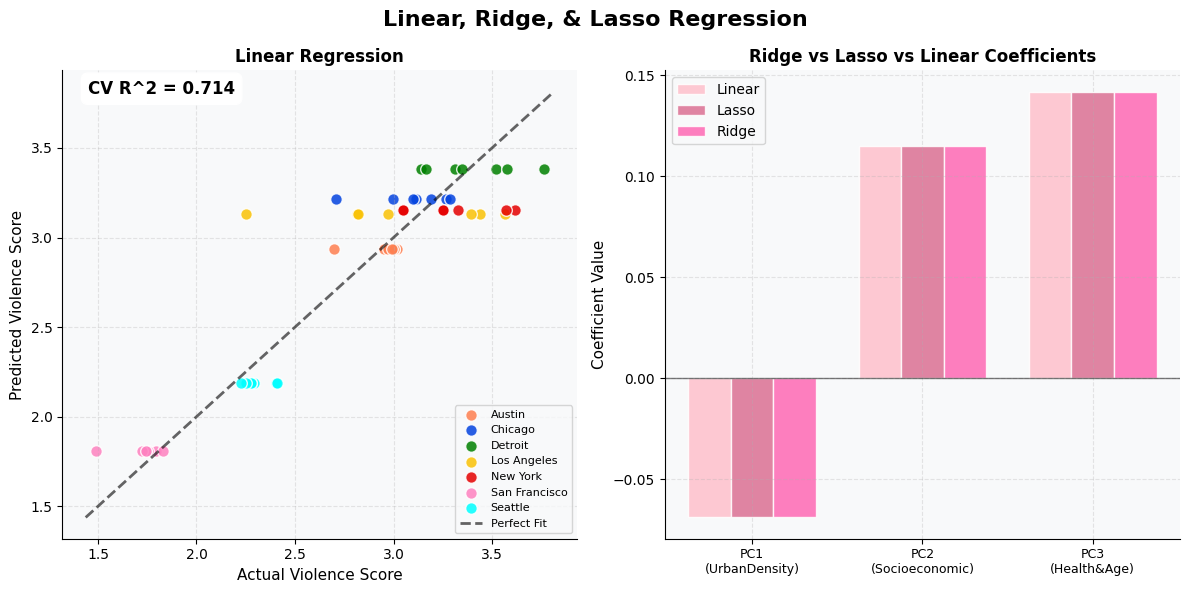

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (12, 6))
fig.suptitle('Linear, Ridge, & Lasso Regression', fontsize = 16, fontweight='bold')

#left side actual vs. predicted
ax = axes[0]

y_pred = lr.predict(X_pca)

for city in sorted(master_df['City'].unique()):
  mask = cities == city
  ax.scatter(y[mask], y_pred[mask],
             c = citycolors[city], label = city,
             s=70, alpha =0.85, edgecolors = 'white')

mn, mx = y.min() - 0.05, y.max() + 0.05
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=2, alpha = 0.6, label = 'Perfect Fit')

lr_r2 = cross_val_score(LinearRegression(), X_pca, y, cv=kf, scoring='r2').mean()
ax.annotate(f'CV R^2 = {lr_r2:.3f}',
            xy = (0.05, 0.95), xycoords = 'axes fraction',
            fontsize = 12, fontweight = 'bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor = 'white'))

ax.set_xlabel('Actual Violence Score', fontsize = 11)
ax.set_ylabel('Predicted Violence Score', fontsize = 11)
ax.set_title('Linear Regression', fontsize = 12, fontweight='bold')
ax.legend(fontsize=8)

#right side
ax = axes[1]
pc_labels = ['PC1\n(UrbanDensity)', 'PC2\n(Socioeconomic)', 'PC3\n(Health&Age)']
x = np.arange(len(pc_labels))
width = 0.25
model_colors = {'Linear': 'pink', 'Lasso': 'palevioletred', 'Ridge': 'hotpink'}

for (name, coefs), offset in zip(
    [('Linear', lr.coef_), ('Lasso', lasso.coef_), ('Ridge', ridge.coef_)],
    [-width, 0, width]
):
  ax.bar(x + offset, coefs, width = width,
         color = model_colors[name], label = name,
         edgecolor = 'white', alpha=0.85)

ax.set_xticks(x)
ax.axhline(0, color = 'black', linewidth=1.0, alpha=0.5)
ax.set_xticklabels(pc_labels, fontsize = 9)
ax.set_ylabel('Coefficient Value', fontsize = 11)
ax.set_title('Ridge vs Lasso vs Linear Coefficients', fontsize = 12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# **Random Forest Prediction Model**

In [ ]:
#random forest prediction model...
#using a maximum depth of 3 since there are only 49 rows to prevent overfitting
rf = RandomForestRegressor(n_estimators=100, max_depth=3,
                           min_samples_leaf=3, random_state=42)
rf.fit(X_pca, y)
rf_scores = evaluate_model("Random Forest", rf, X_pca, y, kf)

Random Forest        R^2: 0.718 +/- 0.127 | RMSE: 0.278 +/- 0.070


In [ ]:
#feature importance for the random forest
importance_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(X_pca.shape[1])],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(f"\n Random Forest feature importances:")
print(importance_df.to_string(index=False))


 Random Forest feature importances:
Component  Importance
      PC3    0.488858
      PC2    0.447998
      PC1    0.063144


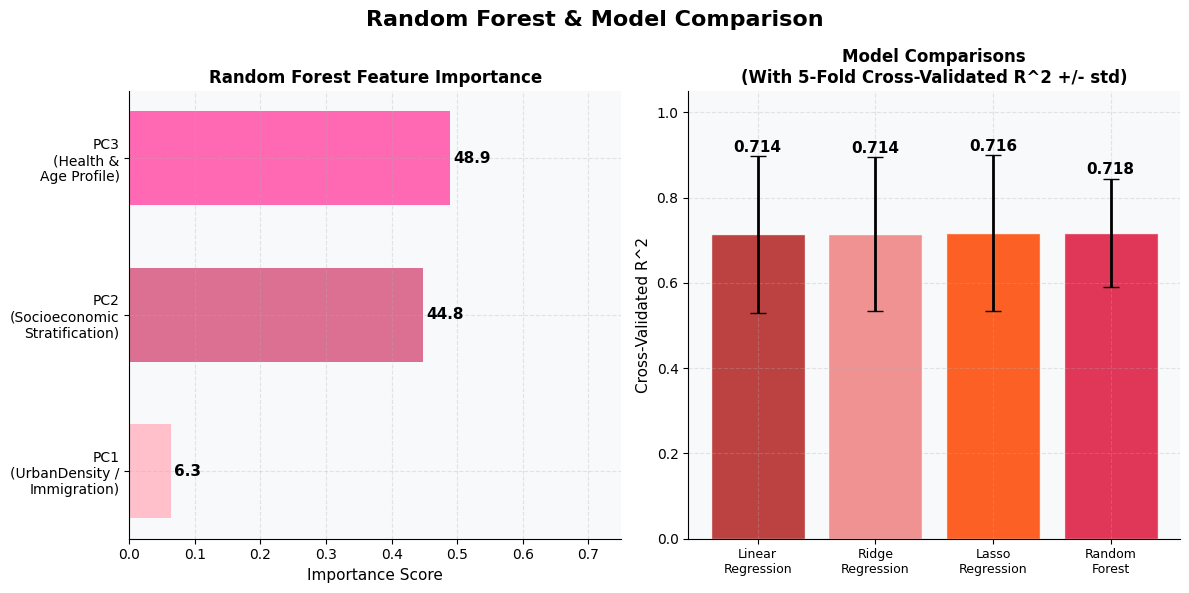

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (12, 6))
fig.suptitle('Random Forest & Model Comparison', fontsize = 16, fontweight='bold')

ax = axes[0]

importances = rf.feature_importances_
pc_labels = ['PC1\n(UrbanDensity /\nImmigration)', 'PC2\n(Socioeconomic\nStratification)', 'PC3\n(Health &\nAge Profile)']

sorted_idx = np.argsort(importances)
bar_colors = ['pink', 'palevioletred', 'hotpink']

bars = ax.barh(
    [pc_labels[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color=[bar_colors[i] for i in sorted_idx],
    height=0.6
)

for bar, val in zip(bars, [importances[i] for i in sorted_idx]):
  ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val*100:.1f}',
          va='center', fontsize = 11, fontweight = 'bold')

ax.set_xlabel('Importance Score', fontsize = 11)
ax.set_title('Random Forest Feature Importance', fontsize = 12, fontweight='bold')
ax.set_xlim(0,0.75)

#right side
ax = axes[1]

model_names = ['Linear\nRegression', 'Ridge\nRegression', 'Lasso\nRegression','Random\nForest']

model_list = [
    LinearRegression(),
    RidgeCV(alphas=[.001,.01,.1,1,10,100], cv = kf),
    LassoCV(cv=kf, random_state=42, max_iter=10000),
    RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf = 3, random_state=42)
]
m_colors = ['firebrick', 'lightcoral', 'orangered', 'crimson']

means, stds = [], []
for model in model_list:
  scores = cross_val_score(model, X_pca, y, cv=kf, scoring='r2')
  means.append(scores.mean())
  stds.append(scores.std())

x_pos = np.arange(len(model_names))
bars = ax.bar(x_pos, means, yerr=stds, color = m_colors, edgecolor = 'white',
              capsize = 6, alpha = 0.85, error_kw={'linewidth':2})

for bar, val, std in zip(bars, means, stds):
  ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.01, f'{val:.3f}',
          ha='center', fontsize = 11, fontweight = 'bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, fontsize = 9)
ax.set_ylabel('Cross-Validated R^2', fontsize = 11)
ax.set_ylim(0,1.05)
ax.set_title('Model Comparisons\n(With 5-Fold Cross-Validated R^2 +/- std)', fontsize = 12, fontweight='bold')

plt.tight_layout()
plt.show()

# **Final Model**

In [ ]:
#final prediction model
rf_final = RandomForestRegressor(n_estimators = 200, max_depth=3,
                                 min_samples_leaf=3, random_state=42)
rf_final.fit(X_pca, y)

def predict_violence(demographic_input: dict) -> float:
  input_df = pd.DataFrame([demographic_input])
  for col in log_cols:
    input_df[f'log_{col}'] = np.log1p(input_df[col])
    input_df.drop(columns=[col], inplace=True)
  input_df = input_df.reindex(columns=features, fill_value = 0)

  input_scaled = scaler.transform(input_df)
  input_pca = pca.transform(input_scaled)

  prediction = rf_final.predict(input_pca)[0]
  return round(prediction, 2)

In [ ]:
city_predict = {
    'Population' : 698447,
    'Income (dollars)' : 80090,
    'Education (percent)' : 50.7,
    'Employment (percent)' : 72.2,
    'HousingUnits' : 369824,
    'Health (percent)' : 12.9,
    'Households' : 331090,
    'Age' : 34.6,
    'Language (percent)' : 20.2,
    'Foreign-born (percent)' : 15.6,
    'Naturalized (percent)' : 37.5,
    'Not Naturalzied (percent)' : 62.5,
    'Older Pop (percent)' : 12.9,
    'Residential Mobility (percent)' : 4.7,
    'Poverty (percent)' : 12.1,
    'High School (percent)' : 19.6,
    "Bachelor's (percent)" : 30.9,
    'Graduate or Professional (percent)' : 19.9,
    'K-12 (percent)' : 60.5,
    'Commuting' : 25.2,
    'Hours Worked' : 38.8,
    'Rent' : 1669,
    'Homeownership Rate (percent)' : 51.8,
    'Disability (percent)' : 10.3,
    'Marital Status (percent )' : 43.4,
    'American Indian and Alaska Native' : 3839,
    'Asian' : 27375,
    'Black or African American' : 169349,
    'Hispanic or Latino' : 96349,
    'Native Hawaiian and Other Pacific Islander' : 318,
    'White' : 380838
 }

In [ ]:
predicted_score = predict_violence(city_predict)
print(f"  Predicted Violence Score: {predicted_score} / 10")
print("\n  Scale reference:")
print("  0-2  → Very low violence")
print("  2-4  → Low violence")
print("  4-6  → Moderate violence")
print("  6-8  → High violence")
print("  8-10 → Very high violence")

  Predicted Violence Score: 2.58 / 10

  Scale reference:
  0-2  → Very low violence
  2-4  → Low violence
  4-6  → Moderate violence
  6-8  → High violence
  8-10 → Very high violence
